## CAR MPG PREDICTION - LINEAR REGRESSION MODEL

##### Import required libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

print('Libraries loaded successfully.')

Libraries loaded successfully.


##### 1. Load Data

In [36]:
# Load dataset
df = pd.read_csv("car.csv")

In [37]:
# Display first few rows
print(df.head())

    MPG  Cylinders  Displacement Horsepower  Weight  Acceleration  Model Year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   US Made  
0        1  
1        1  
2        1  
3        1  
4        1  


##### 2. Initial EDA

In [38]:
# Shape of dataset
df.shape

(398, 8)

In [39]:
# Column names
df.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'US Made'],
      dtype='object')

In [40]:
# Info (data types)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    object 
 4   Weight        398 non-null    int64  
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   US Made       398 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB
None


In [41]:
# Summary statistics
df.describe()

,MPG,Cylinders,Displacement,Weight,Acceleration,Model Year,US Made
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,0.625628
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.484569
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,0.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,0.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,1.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,1.000000


In [42]:
# Missing values
df.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64

In [43]:
# Number of unique values per column
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Unique values per column:
MPG: 129
Cylinders: 5
Displacement: 82
Horsepower: 94
Weight: 351
Acceleration: 95
Model Year: 13
US Made: 2


In [44]:
# Unique values per column
print("\nUnique values per column:\n")
for col in df.columns:
    print(f"{col}:\n {df[col].unique()}\n")


Unique values per column:

MPG:
 [18.  15.  16.  17.  14.  24.  22.  21.  27.  26.  25.  10.  11.   9.
 28.  19.  12.  13.  23.  30.  31.  35.  20.  29.  32.  33.  17.5 15.5
 14.5 22.5 24.5 18.5 29.5 26.5 16.5 31.5 36.  25.5 33.5 20.5 30.5 21.5
 43.1 36.1 32.8 39.4 19.9 19.4 20.2 19.2 25.1 20.6 20.8 18.6 18.1 17.7
 27.5 27.2 30.9 21.1 23.2 23.8 23.9 20.3 21.6 16.2 19.8 22.3 17.6 18.2
 16.9 31.9 34.1 35.7 27.4 25.4 34.2 34.5 31.8 37.3 28.4 28.8 26.8 41.5
 38.1 32.1 37.2 26.4 24.3 19.1 34.3 29.8 31.3 37.  32.2 46.6 27.9 40.8
 44.3 43.4 36.4 44.6 40.9 33.8 32.7 23.7 23.6 32.4 26.6 25.8 23.5 39.1
 39.  35.1 32.3 37.7 34.7 34.4 29.9 33.7 32.9 31.6 28.1 30.7 24.2 22.4
 34.  38.  44. ]

Cylinders:
 [8 4 6 3 5]

Displacement:
 [307.  350.  318.  304.  302.  429.  454.  440.  455.  390.  383.  340.
 400.  113.  198.  199.  200.   97.  110.  107.  104.  121.  360.  140.
  98.  232.  225.  250.  351.  258.  122.  116.   79.   88.   71.   72.
  91.   97.5  70.  120.   96.  108.  155.   68.  114. 

##### 3. Data Cleaning

In [45]:
# Convert Horsepower to numeric (handle '?' or invalid values)
df['Horsepower'] = pd.to_numeric(df['Horsepower'], errors='coerce')

In [46]:
# Check missing after conversion
print("\nMissing after conversion:")
print(df.isnull().sum())


Missing after conversion:
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


In [50]:
# Fill missing with median
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].median())

In [49]:
# Final check
print("\nMissing after cleaning:")
print(df.isnull().sum())


Missing after cleaning:
MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


In [71]:
# Summary statistics after cleaning
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,US Made
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,0.625628
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.484569
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,0.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,1.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,1.000000


##### 4. Visual EDA

In [ ]:
# Correlation matrix
df.corr()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,US Made
MPG,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267,-0.568192
Cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746,0.604351
Displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164,0.651407
Horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733,0.485418
Weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564,0.598398
Acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137,-0.250806
Model Year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000,-0.139883
US Made,-0.568192,0.604351,0.651407,0.485418,0.598398,-0.250806,-0.139883,1.000000


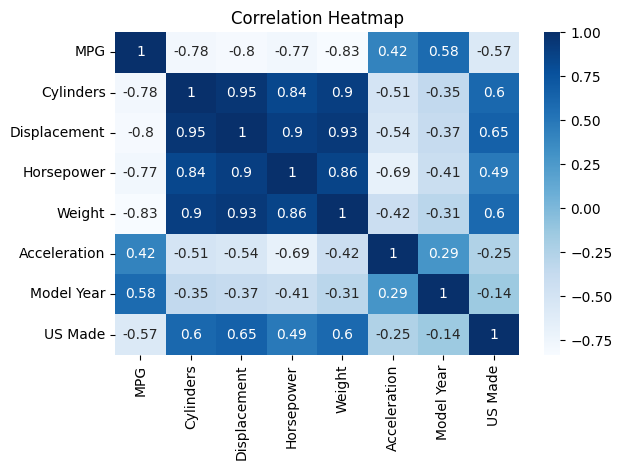

In [68]:
# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

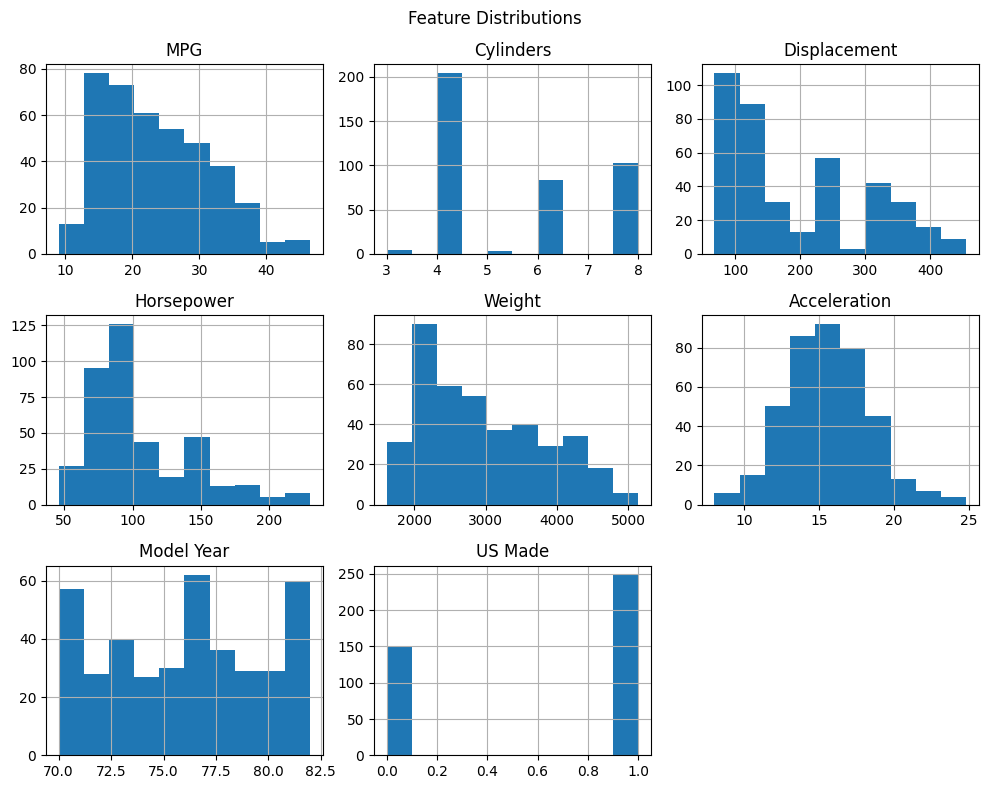

In [66]:
# Histograms for all variables
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

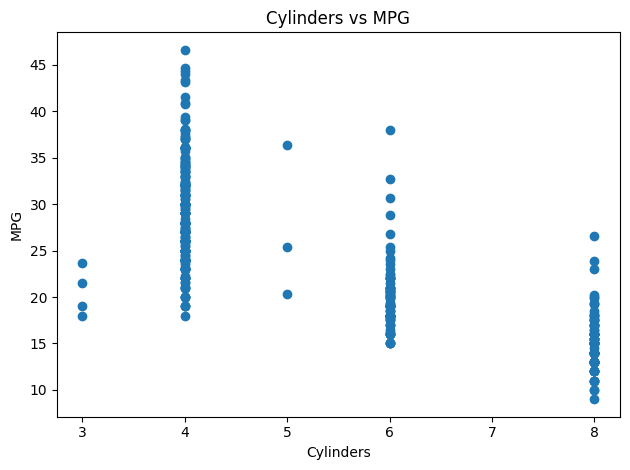

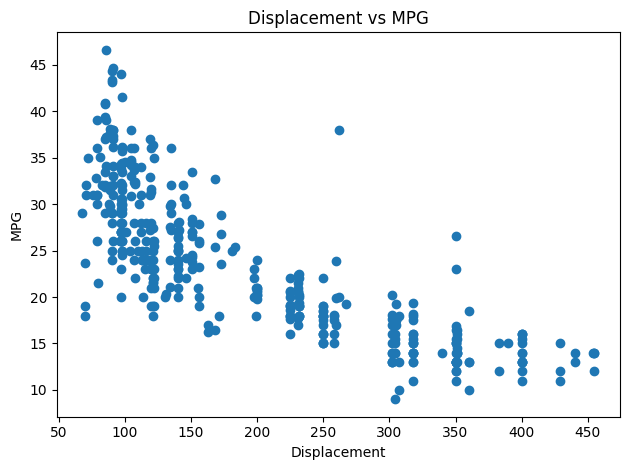

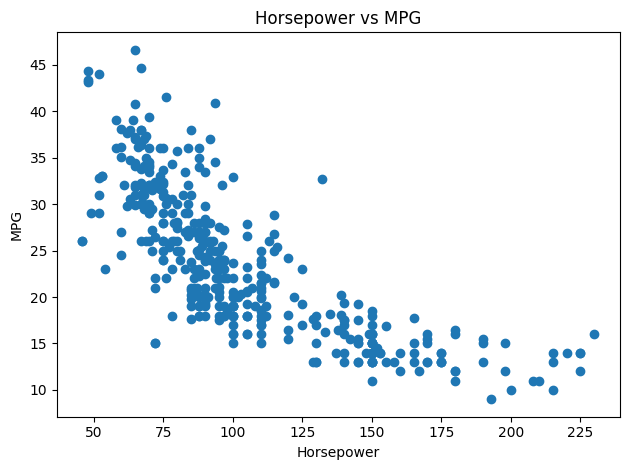

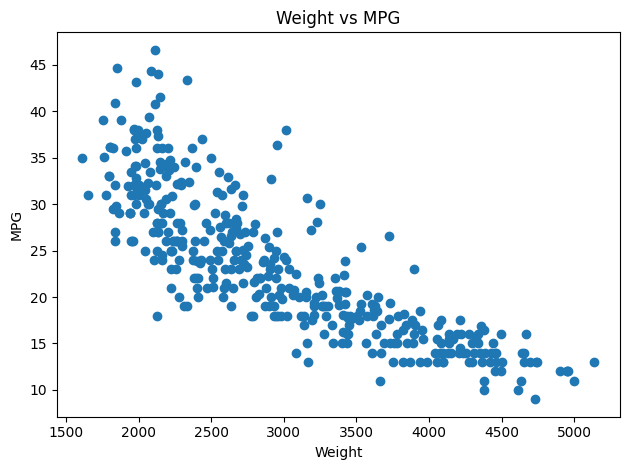

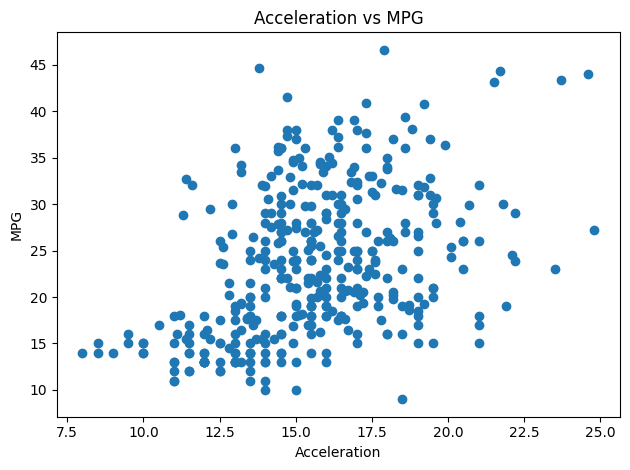

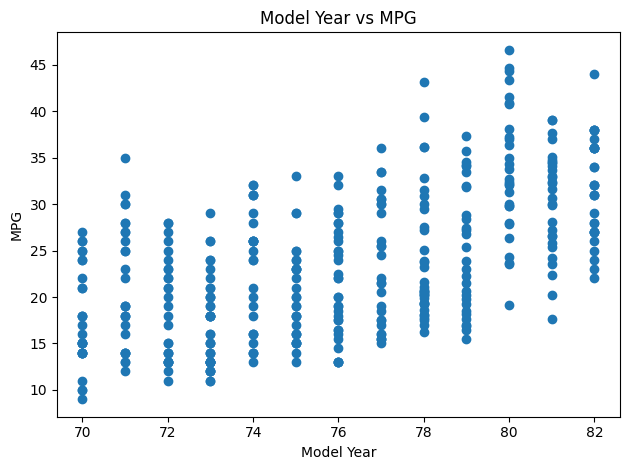

In [69]:
# Scatter plots vs MPG
features = ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year']

for feature in features:
    plt.figure()
    plt.scatter(df[feature], df['MPG'])
    plt.xlabel(feature)
    plt.ylabel("MPG")
    plt.title(f"{feature} vs MPG")
    plt.tight_layout()
    plt.show()

##### 5. Define Feature and Target

In [56]:
y = df['MPG']
X = df.drop(columns=['MPG'])

# Add constant for statsmodels
X_sm = sm.add_constant(X)

##### 6. Train-Test Split

In [58]:
# Train-test split (80% training data, 20% testing data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### 7. Build Linear Regression Model

In [59]:
# Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
# Predictions
y_pred = model.predict(X_test)

In [61]:
# Evaluation
print("\nModel Performance:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Model Performance:
MSE: 8.264997943522351
R2 Score: 0.8462796241099292


##### 8. Model Interpretation (OLS)

In [63]:
model_sm = sm.OLS(y, X_sm).fit()
print("\nFull Model Summary:\n")
print(model_sm.summary())


Full Model Summary:

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     261.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          4.30e-143
Time:                        18:21:38   Log-Likelihood:                -1036.3
No. Observations:                 398   AIC:                             2089.
Df Residuals:                     390   BIC:                             2120.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -15.9632   

##### 9. Feature Selection (Optimization)

In [64]:
# Optimized feature set based on statistical significance
X_opt = df[['Displacement', 'Weight', 'Model Year', 'US Made']]

# Add constant
X_opt_sm = sm.add_constant(X_opt)

# Fit optimized model
model_opt = sm.OLS(y, X_opt_sm).fit()

print("\nOptimized Model Summary:\n")
print(model_opt.summary())


Optimized Model Summary:

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     452.2
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.43e-145
Time:                        18:25:05   Log-Likelihood:                -1039.7
No. Observations:                 398   AIC:                             2089.
Df Residuals:                     393   BIC:                             2109.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.08

##### 10. Feature Importance

In [65]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Impact on MPG:\n")
print(coefficients.sort_values(by="Coefficient", ascending=False))


Feature Impact on MPG:

        Feature  Coefficient
5    Model Year     0.821615
4  Acceleration     0.067460
1  Displacement     0.019706
3        Weight    -0.006993
2    Horsepower    -0.015214
0     Cylinders    -0.176177
6       US Made    -2.804507
